# 05 — Customer Complaint Clustering (SBERT + KMeans)

Uses `sentence-transformers/all-MiniLM-L6-v2` to embed negative/complaint reviews, then clusters them with **KMeans** per `product_id` to automatically surface recurring complaint themes — no manual labelling required.

In [1]:
import sys
import os
import glob
import warnings
from typing import List, Dict
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

DATA_DIR = os.path.abspath("../data/processed/sentiment")
OUT_DIR  = DATA_DIR

print("Libraries loaded.")

Libraries loaded.


## 1. Load Complaint Reviews

Load negative reviews from `sentiment_scored/` (notebook 03 output).  
Falls back to `*_processed.parquet` filtered by `sentiment_label == negative`.

In [2]:
SENTIMENT_SCORED  = os.path.join(DATA_DIR, "sentiment_scored")
SAMPLE_PER_FILE   = 3000
NEEDED_COLS_SCORED = ["product_id", "product_title", "product_category", "review", "roberta_label"]
NEEDED_COLS_RAW    = ["product_id", "product_title", "product_category", "review", "sentiment_label"]

if os.path.isdir(SENTIMENT_SCORED):
    parts = glob.glob(f"{SENTIMENT_SCORED}/*.parquet")
    df = pd.concat(
        [pd.read_parquet(p, columns=NEEDED_COLS_SCORED) for p in parts],
        ignore_index=True
    ).rename(columns={"roberta_label": "sentiment"})
    print(f"Loaded sentiment_scored: {len(df):,} rows")
else:
    parquet_files = sorted(glob.glob(f"{DATA_DIR}/*_processed.parquet"))
    print(f"sentiment_scored not found — loading {len(parquet_files)} raw parquets...")
    frames = []
    for path in parquet_files:
        tmp = pd.read_parquet(path, columns=NEEDED_COLS_RAW).rename(
            columns={"sentiment_label": "sentiment"}
        )
        frames.append(tmp.sample(min(SAMPLE_PER_FILE, len(tmp)), random_state=42))
    df = pd.concat(frames, ignore_index=True)
    print(f"Loaded {len(df):,} rows from raw parquets")

df["sentiment"] = df["sentiment"].str.lower().str.strip()
df = df[df["product_id"].notna() & df["review"].notna()].copy()
df["review"] = df["review"].astype(str).str[:600]

# Keep only negative reviews
complaints = df[df["sentiment"] == "negative"].reset_index(drop=True)

print(f"\nTotal negative reviews : {len(complaints):,}")
print(f"Unique products        : {complaints['product_id'].nunique():,}")
print(f"Categories             : {sorted(complaints['product_category'].dropna().unique())}")

Loaded sentiment_scored: 30,000 rows

Total negative reviews : 5,201
Unique products        : 4,826
Categories             : ['Apparel', 'Beauty', 'Books', 'Furniture', 'Mobile_Apps', 'Outdoors']


## 2. Load SBERT Model

In [3]:
SBERT_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
sbert = SentenceTransformer(SBERT_MODEL)
print(f"Model loaded: {SBERT_MODEL}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10338.21it/s]


Model loaded: sentence-transformers/all-MiniLM-L6-v2


## 3. Cluster Complaints per Product

For each product with ≥ `MIN_COMPLAINTS` negative reviews:
1. Encode reviews with SBERT → dense embeddings
2. Run KMeans to group into complaint clusters
3. Extract top TF-IDF keywords per cluster as the **theme label**

In [4]:
MIN_COMPLAINTS = 5   # skip products with fewer negative reviews
N_CLUSTERS     = 3   # complaint themes per product
TOP_KEYWORDS   = 5   # keywords per cluster label

def get_cluster_label(texts: List[str], top_n: int = TOP_KEYWORDS) -> str:
    """Return top TF-IDF terms for a group of texts as a readable theme label."""
    if len(texts) == 0:
        return ""
    tfidf = TfidfVectorizer(stop_words="english", max_features=200)
    try:
        matrix = tfidf.fit_transform(texts)
    except ValueError:
        return " ".join(texts[0].split()[:top_n])
    scores = np.asarray(matrix.mean(axis=0)).flatten()
    top_idx = scores.argsort()[::-1][:top_n]
    vocab = tfidf.get_feature_names_out()
    return ", ".join(vocab[i] for i in top_idx)


rows: List[Dict] = []
product_groups = complaints.groupby("product_id")
eligible = [(pid, grp) for pid, grp in product_groups if len(grp) >= MIN_COMPLAINTS]
print(f"Products with ≥ {MIN_COMPLAINTS} complaints: {len(eligible):,}")

for product_id, grp in tqdm(eligible, desc="Clustering"):
    texts  = grp["review"].tolist()
    k      = min(N_CLUSTERS, len(texts))
    meta   = grp.iloc[0]

    embeddings = sbert.encode(texts, show_progress_bar=False, batch_size=32)
    km         = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels     = km.fit_predict(embeddings)

    for cluster_id in range(k):
        mask          = labels == cluster_id
        cluster_texts = [t for t, m in zip(texts, mask) if m]
        rows.append({
            "product_id"       : product_id,
            "product_title"    : meta["product_title"],
            "product_category" : meta["product_category"],
            "cluster_id"       : cluster_id,
            "complaint_count"  : int(mask.sum()),
            "theme_keywords"   : get_cluster_label(cluster_texts),
            "sample_review"    : cluster_texts[0] if cluster_texts else "",
        })

cluster_df = pd.DataFrame(rows)
print(f"\nTotal clusters : {len(cluster_df):,}")
print(f"Products covered: {cluster_df['product_id'].nunique():,}")
cluster_df.head(6)

Products with ≥ 5 complaints: 12


Clustering: 100%|██████████| 12/12 [00:04<00:00,  2.85it/s]


Total clusters : 36
Products covered: 12


,product_id,product_title,product_category,cluster_id,complaint_count,theme_keywords,sample_review
0,0060761288,100 People Who Are Screwing Up America (And Al...,Books,0,2,"garbage, jimmy, carter, list, 100",jimmy carter isn't ruining america. jimmy cart...
1,0060761288,100 People Who Are Screwing Up America (And Al...,Books,1,3,"goldberg, book, does, al, franken",goldberg nails them.. this book does a great j...
2,0060761288,100 People Who Are Screwing Up America (And Al...,Books,2,1,"policies, country, 000, result, casualties",wake up. who cares if limousine liberals are c...
3,0975599518,"Natural Cures ""They"" Don't Want You to Know about",Books,0,1,"don, buy, whatsoever, depends, health",don't buy this - your health depends on it!. k...
4,0975599518,"Natural Cures ""They"" Don't Want You to Know about",Books,1,5,"book, information, cures, don, trudeau","waste of time and money, even for a natural he..."
5,0975599518,"Natural Cures ""They"" Don't Want You to Know about",Books,2,5,"book, fraud, money, trudeau, yes",kevin trudeau is a fraud. this guy copped a pl...


## 4. Inspect — Per-Product Complaint Themes

In [5]:
pd.set_option("display.max_colwidth", 100)

# Pick the product with the most complaints as a demo
top_product_id = (
    cluster_df.groupby("product_id")["complaint_count"].sum()
    .idxmax()
)
sample = cluster_df[cluster_df["product_id"] == top_product_id]

print("=" * 70)
print(f"Product : {sample.iloc[0]['product_title']}")
print(f"Category: {sample.iloc[0]['product_category']}")
print(f"ID      : {top_product_id}")
print("=" * 70)
for _, row in sample.iterrows():
    print(f"\n  Cluster {row['cluster_id']}  ({row['complaint_count']} reviews)")
    print(f"  Theme   : {row['theme_keywords']}")
    print(f"  Sample  : {row['sample_review'][:200]}")

Product : Amazon Prime Video
Category: Mobile_Apps
ID      : B00N28818A

  Cluster 0  (8 reviews)
  Theme   : video, prime, amazon, people, app
  Sample  : really, that difficult to get phone app?. this is bs. my trial will expire and i'll opt for services that don't make it hard for their customers. ridiculous

  Cluster 1  (7 reviews)
  Theme   : star, pay, stars, good, watch
  Sample  : five stars. ok . you prices are not competitive with netfli

  Cluster 2  (9 reviews)
  Theme   : work, tablet, watch, support, device
  Sample  : used to work on my note 4. it was working fine. then next thing you know my device was no longer supported. amazon being an idiot makes you jump through hoops to get you to install this app. then rand


## 5. Visualisations

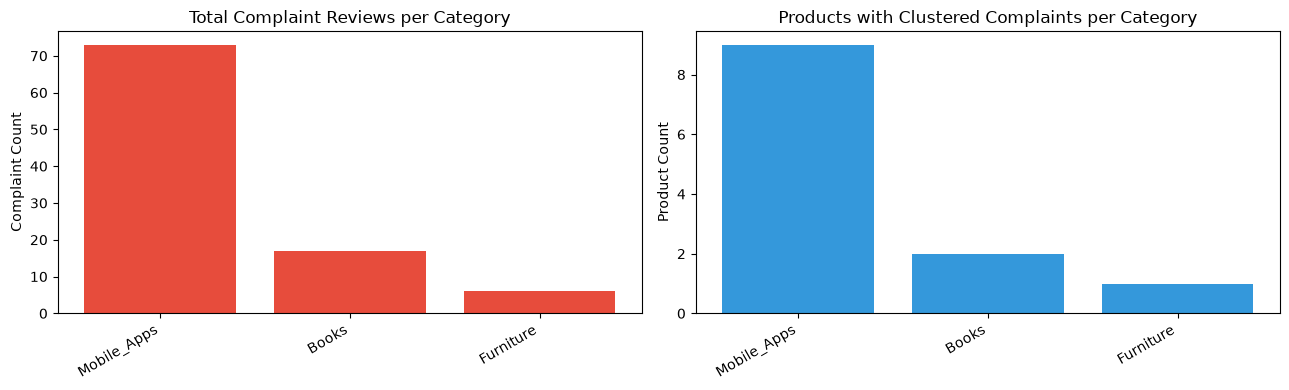

In [6]:
# --- Chart 1: Total complaints per category ---
cat_counts = (
    cluster_df.groupby("product_category")["complaint_count"]
    .sum()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(len(cat_counts)), cat_counts.values, color="#e74c3c")
axes[0].set_xticks(range(len(cat_counts)))
axes[0].set_xticklabels(cat_counts.index, rotation=30, ha="right")
axes[0].set_title("Total Complaint Reviews per Category")
axes[0].set_ylabel("Complaint Count")

# --- Chart 2: Products per category with clustered complaints ---
prod_per_cat = (
    cluster_df.drop_duplicates("product_id")
    .groupby("product_category")["product_id"]
    .count()
    .sort_values(ascending=False)
)

axes[1].bar(range(len(prod_per_cat)), prod_per_cat.values, color="#3498db")
axes[1].set_xticks(range(len(prod_per_cat)))
axes[1].set_xticklabels(prod_per_cat.index, rotation=30, ha="right")
axes[1].set_title("Products with Clustered Complaints per Category")
axes[1].set_ylabel("Product Count")

plt.tight_layout()
plt.show()

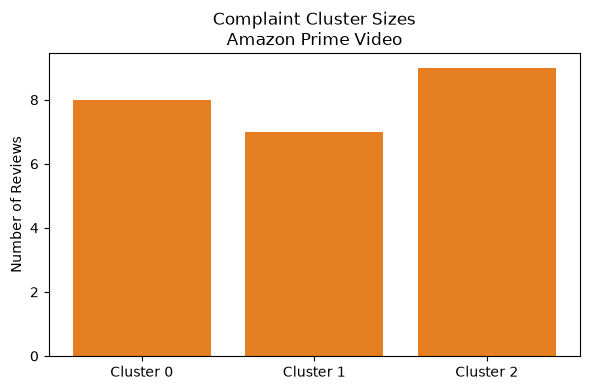

In [7]:
# --- Chart 3: Cluster size distribution for the top demo product ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    [f"Cluster {r['cluster_id']}" for _, r in sample.iterrows()],
    sample["complaint_count"].values,
    color="#e67e22"
)
ax.set_title(f"Complaint Cluster Sizes\n{sample.iloc[0]['product_title'][:60]}")
ax.set_ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

## 6. Save Results

In [8]:
OUT_PATH = os.path.join(OUT_DIR, "complaint_clusters.parquet")
cluster_df.to_parquet(OUT_PATH, index=False)
print(f"Saved {len(cluster_df):,} cluster rows → {OUT_PATH}")
print("\nSchema:")
print(cluster_df.dtypes)
print("\nSample:")
print(cluster_df[["product_id", "product_category", "cluster_id",
                   "complaint_count", "theme_keywords"]].head(6).to_string(index=False))

Saved 36 cluster rows → /Users/varsha/Documents/GitHub/product-review-intelligence-platform/data/processed/sentiment/complaint_clusters.parquet

Schema:
product_id            str
product_title         str
product_category      str
cluster_id          int64
complaint_count     int64
theme_keywords        str
sample_review         str
dtype: object

Sample:
product_id product_category  cluster_id  complaint_count                             theme_keywords
0060761288            Books           0                2          garbage, jimmy, carter, list, 100
0060761288            Books           1                3          goldberg, book, does, al, franken
0060761288            Books           2                1 policies, country, 000, result, casualties
0975599518            Books           0                1      don, buy, whatsoever, depends, health
0975599518            Books           1                5     book, information, cures, don, trudeau
0975599518            Books           2   